# LATINO v2: Latent-Space Implementation

**Matching the reference `main_LATINO.py` + `noise_schemes.py`**

Key difference from v1: everything stays in latent space.
The proximal step modifies the noise prediction, and `scheduler.step()` updates the latents.

```
latents = encode(x_init) + scheduler_noise
for each timestep:
    noise_pred = UNet(latents, t)
    z0 = Tweedie(latents, noise_pred)       # estimate clean latent
    x  = VAE.decode(z0)                     # decode to image
    px = prox_l2(x, y, gamma)               # proximal in image space
    z0_corr = VAE.encode(px)                # re-encode corrected image
    noise_corr = to_noise_pred(z0_corr)     # convert back to noise format
    latents = scheduler.step(noise_corr)    # scheduler updates latents
result = VAE.decode(latents)                # final decode
```

## 1. Install Dependencies

In [1]:
!pip install -q diffusers transformers accelerate deepinv huggingface_hub

## 2. Imports

In [2]:
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import random

from diffusers import (
    AutoencoderKL,
    DiffusionPipeline,
    UNet2DConditionModel,
    LCMScheduler,
)
from huggingface_hub import hf_hub_download
import deepinv as dinv
from torchvision.utils import save_image
from torchvision import transforms
from PIL import Image

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


PyTorch: 2.9.0+cu128
CUDA available: True
GPU: Tesla T4


## 3. Configuration

In [3]:
# ---- Experiment parameters (edit these) ----
IMAGE_PATH   = "sample.png"
SCALE_FACTOR = 16                      # downsampling factor (paper default: x16)
N            = 8                       # LATINO iterations (4 or 8)
SIGMA_Y      = 0.01                    # observation noise std-dev (paper default for x16)
PROMPT       = "a photo of a face"     # text conditioning (matches reference config)
INIT_STRATEGY = "y_noise"              # 'y' (deterministic) or 'y_noise' (noisy init)
SEED         = 42
OUTPUT_DIR   = "output_v2"

# Auto-select device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

divisor = SCALE_FACTOR * 8
TARGET_SIZE = (1024 // divisor) * divisor
print(f"Target size: {TARGET_SIZE}x{TARGET_SIZE}  (divisible by {divisor})")

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

Using device: cuda
Target size: 1024x1024  (divisible by 128)


## 4. Define LATINO v2 Components

In [4]:
# ============================================================
# Model Loading
# ============================================================

def load_pipeline(device="cuda"):
    """Load SDXL pipeline with DMD2 4-step distilled UNet and LCM scheduler."""
    vae = AutoencoderKL.from_pretrained(
        "madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16
    )

    base_model_id = "stabilityai/stable-diffusion-xl-base-1.0"
    unet_config = UNet2DConditionModel.load_config(base_model_id, subfolder="unet")
    unet = UNet2DConditionModel.from_config(unet_config).to(device, torch.float16)
    unet.load_state_dict(
        torch.load(
            hf_hub_download("tianweiy/DMD2", "dmd2_sdxl_4step_unet_fp16.bin"),
            map_location=device,
            weights_only=True,
        )
    )

    pipe = DiffusionPipeline.from_pretrained(
        base_model_id,
        unet=unet,
        vae=vae,
        torch_dtype=torch.float16,
        variant="fp16",
    ).to(device)
    pipe.scheduler = LCMScheduler.from_config(pipe.scheduler.config)

    # Force VAE to float32 -- SDXL VAE is numerically unstable in float16
    pipe.vae = pipe.vae.to(dtype=torch.float32)

    return pipe


# ============================================================
# Noise Prediction with Data-Fidelity Guidance
# (from noise_schemes.py :: noise_pred_cond_y)
# ============================================================

def noise_pred_cond_y(latents, t, pipe, y_guidance, physics, noise_pred,
                      sigma_y, scale_factor=4):
    """
    Modify noise prediction with proximal data-fidelity step.

    1. Tweedie formula  -> z0 estimate
    2. Decode z0 to image space
    3. Apply prox_l2 for data consistency
    4. Re-encode corrected image to latent space
    5. Convert corrected z0 back to noise-prediction format
    """
    with torch.no_grad():
        t_int = int(t)
        alpha_t = pipe.scheduler.alphas_cumprod[t_int]

        # 1) Tweedie: estimate clean latent z0
        z0_pred = (
            torch.sqrt(1.0 / alpha_t)
            * (latents - torch.sqrt(1.0 - alpha_t) * noise_pred)
        )

        # 2) Decode to image space [-1, 1]
        x = pipe.vae.decode(
            z0_pred.to(dtype=pipe.vae.dtype) / pipe.vae.config.scaling_factor
        ).sample.clip(-1, 1)

        # 3) Data fidelity
        df = torch.norm(physics.A(x.float()) - y_guidance).item()

        # Adaptive delta (reference values for SR)
        if scale_factor <= 16:
            delta = 3.0 * df / 10.0 if t_int > 300 else 2.0 * df / 10.0
        else:
            delta = 1.5 * df / 10.0 if t_int > 300 else 3.0 * df / 10.0

        # gamma = delta * (1 - alpha_t) / sigma_y^2
        var_x_zt = 1.0 - alpha_t.item()
        gamma = delta * var_x_zt / (sigma_y ** 2)

        # Proximal step in image space
        prox_x = physics.prox_l2(x.float(), y=y_guidance, gamma=gamma)

        # 4) Re-encode to latent space
        qz = pipe.vae.encode(prox_x.clip(-1, 1).to(dtype=pipe.vae.dtype))
        mu_z = qz.latent_dist.mean * pipe.vae.config.scaling_factor
        z0_cond = mu_z.to(dtype=latents.dtype)

        # 5) Convert corrected z0 back to noise-prediction format
        #    noise = sqrt(1/(1-a)) * z_t  -  sqrt(a/(1-a)) * z0
        alpha_dev = alpha_t.to(device=latents.device, dtype=latents.dtype)
        noise_cond = (
            torch.sqrt(1.0 / (1.0 - alpha_dev)) * latents
            - torch.sqrt(alpha_dev / (1.0 - alpha_dev)) * z0_cond
        )

    return z0_cond, noise_cond, delta, df


# ============================================================
# Metrics
# ============================================================

def compute_psnr(pred, target):
    """Peak Signal-to-Noise Ratio (assumes [0, 1] range)."""
    mse = F.mse_loss(pred, target)
    if mse == 0:
        return float("inf")
    return (10 * torch.log10(1.0 / mse)).item()


# ============================================================
# LATINO v2  --  Latent-space algorithm (reference impl)
# ============================================================

@torch.no_grad()
def latino_v2(pipe, y, physics, prompt="a high quality photo", N=8,
              sigma_y=0.05, scale_factor=4, init_strategy="y_noise",
              seed=42, device="cuda", verbose=True):
    """
    LATINO v2: Latent-space implementation matching main_LATINO.py.

    Instead of encode->noise->denoise->decode->proximal each step,
    this version keeps everything in latent space and uses
    scheduler.step() for updates.
    """
    # Reproducibility
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    vae = pipe.vae
    s = vae.config.scaling_factor

    # All guidance operates in [-1, 1]
    y_norm = (y * 2 - 1).float()
    sigma_y_norm = sigma_y * 2

    # Infer target size
    B, C, H_low, W_low = y.shape
    H, W = H_low * scale_factor, W_low * scale_factor

    # ---- Encode text prompt ----
    text_embeddings, _, pooled_text_embeds, _ = pipe.encode_prompt(
        prompt, device=device, num_images_per_prompt=1,
        do_classifier_free_guidance=False,
    )

    # SDXL additional conditioning
    time_ids = torch.tensor(
        [[H, W, 0, 0, H, W]], device=device, dtype=torch.float16,
    )
    added_cond_kwargs = {
        "text_embeds": pooled_text_embeds,
        "time_ids": time_ids,
    }

    # ---- Set scheduler timesteps ----
    pipe.scheduler.set_timesteps(N, device=device)
    step_size = 1000 // N
    custom_timesteps = torch.tensor(
        [999 - i * step_size for i in range(N)],
        device=device, dtype=torch.long,
    )
    pipe.scheduler.timesteps = custom_timesteps
    if verbose:
        print(f"Timesteps: {custom_timesteps.tolist()}")

    # ---- Initialize latents from x_init ----
    x_init = F.interpolate(
        y_norm, size=(H, W), mode="bicubic", align_corners=False
    ).clamp(-1, 1)

    qz = vae.encode(x_init.to(dtype=vae.dtype))
    mu_z = qz.latent_dist.mean * s

    if init_strategy == "y_noise":
        noise = torch.randn_like(mu_z)
        latents = pipe.scheduler.add_noise(
            mu_z, noise=noise, timesteps=torch.tensor([999])
        )
        if verbose:
            print(f"Init: y_noise (encoded x_init + scheduler noise at t=999)")
    else:
        latents = mu_z
        if verbose:
            print(f"Init: y (encoded x_init, deterministic)")

    latents = latents.to(dtype=pipe.unet.dtype)

    # ---- Main loop ----
    pbar = (
        tqdm(enumerate(pipe.scheduler.timesteps),
             total=len(pipe.scheduler.timesteps), desc="LATINO v2")
        if verbose else enumerate(pipe.scheduler.timesteps)
    )

    for i, timestep in pbar:
        # UNet forward pass
        noise_uncond = pipe.unet(
            latents, timestep,
            encoder_hidden_states=text_embeddings,
            added_cond_kwargs=added_cond_kwargs,
        ).sample

        # Data-fidelity guidance via proximal step
        _, noise_pred, delta_k, df = noise_pred_cond_y(
            latents=latents, t=timestep, pipe=pipe,
            y_guidance=y_norm, physics=physics,
            noise_pred=noise_uncond, sigma_y=sigma_y_norm,
            scale_factor=scale_factor,
        )

        # Scheduler step: update latents
        latents = pipe.scheduler.step(
            noise_pred, timestep, latents
        ).prev_sample

        if verbose:
            pbar.set_postfix(
                t=timestep.item(), delta=f"{delta_k:.2f}", df=f"{df:.2f}"
            )

    # ---- Final decode ----
    decoded = vae.decode(latents.to(dtype=vae.dtype) / s).sample
    restored = (decoded / 2 + 0.5).clamp(0, 1)
    return restored


print("All components defined.")

All components defined.


## 5. Download / Load Image

In [5]:
!pip install -q datasets
from datasets import load_dataset
ds = load_dataset("mattymchen/celeba-hq", split="train", streaming=True)
sample = next(iter(ds))
sample["image"].save("sample.png")
IMAGE_PATH = "sample.png"

image = sample["image"].convert("RGB")
transform = transforms.Compose([
    transforms.Resize(TARGET_SIZE),
    transforms.CenterCrop((TARGET_SIZE, TARGET_SIZE)),
    transforms.ToTensor(),
])
gt = transform(image).unsqueeze(0).to(device)
print(f"Ground truth shape: {gt.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Ground truth shape: torch.Size([1, 3, 1024, 1024])


## 6. Create Degraded Observation

Observation y shape: torch.Size([1, 3, 64, 64])
Bicubic baseline PSNR: 19.15 dB


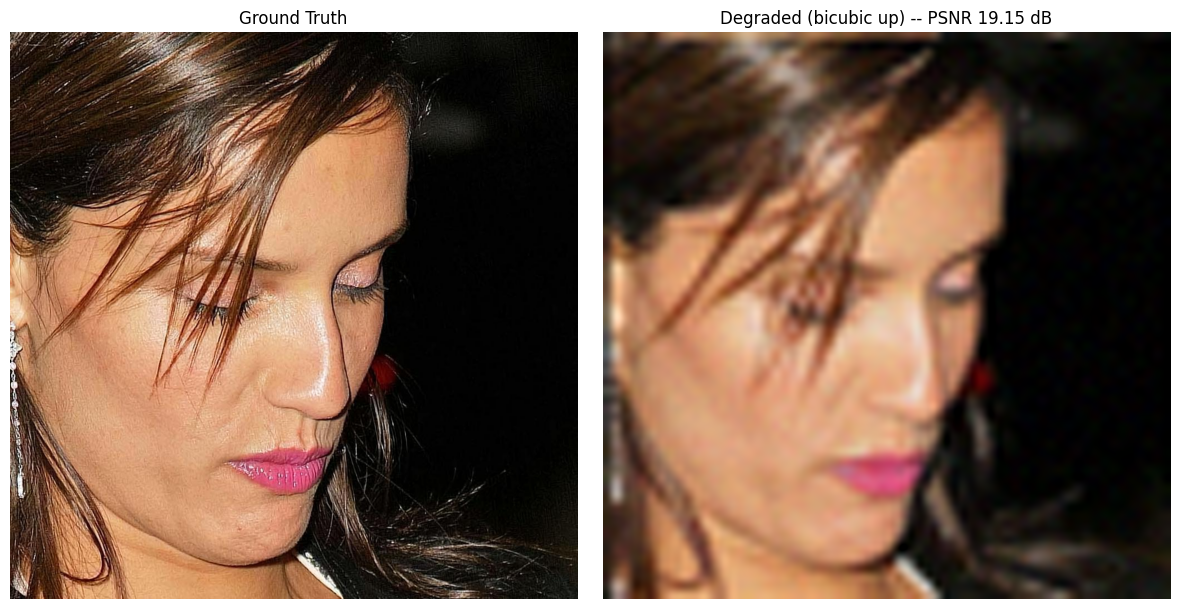

In [6]:
physics = dinv.physics.Downsampling(
    img_size=(3, TARGET_SIZE, TARGET_SIZE),
    factor=SCALE_FACTOR,
    filter="bicubic",
    device=device,
)

y = physics.A(gt)
if SIGMA_Y > 0:
    y = y + SIGMA_Y * torch.randn_like(y)
    y = y.clamp(0.0, 1.0)

print(f"Observation y shape: {y.shape}")

# Bicubic baseline
y_up = F.interpolate(y, size=(TARGET_SIZE, TARGET_SIZE),
                     mode="bicubic", align_corners=False).clamp(0, 1)
baseline_psnr = compute_psnr(y_up, gt)
print(f"Bicubic baseline PSNR: {baseline_psnr:.2f} dB")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(gt[0].cpu().permute(1, 2, 0))
axes[0].set_title("Ground Truth")
axes[0].axis("off")
axes[1].imshow(y_up[0].cpu().permute(1, 2, 0))
axes[1].set_title(f"Degraded (bicubic up) -- PSNR {baseline_psnr:.2f} dB")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 7. Load SDXL + DMD2 Pipeline

In [7]:
pipe = load_pipeline(device=device)
print("Pipeline loaded.")
print(f"  Scheduler: {pipe.scheduler.__class__.__name__}")
print(f"  Prediction type: {pipe.scheduler.config.prediction_type}")
print(f"  VAE dtype: {pipe.vae.dtype}")
print(f"  UNet dtype: {pipe.unet.dtype}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

The config attributes {'skip_prk_steps': True} were passed to LCMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


Pipeline loaded.
  Scheduler: LCMScheduler
  Prediction type: epsilon
  VAE dtype: torch.float32
  UNet dtype: torch.float16


## 8. Run LATINO v2

In [8]:
result = latino_v2(
    pipe, y, physics,
    prompt=PROMPT,
    N=N,
    sigma_y=SIGMA_Y,
    scale_factor=SCALE_FACTOR,
    init_strategy=INIT_STRATEGY,
    seed=SEED,
    device=device,
    verbose=True,
)

latino_psnr = compute_psnr(result, gt)
print(f"\nLATINO v2 PSNR: {latino_psnr:.2f} dB  (baseline: {baseline_psnr:.2f} dB)")

Timesteps: [999, 874, 749, 624, 499, 374, 249, 124]
Init: y_noise (encoded x_init + scheduler noise at t=999)


LATINO v2: 100%|██████████| 8/8 [00:37<00:00,  4.64s/it, delta=1.26, df=6.28, t=124]  



LATINO v2 PSNR: 20.92 dB  (baseline: 19.15 dB)


## 9. Visualise Results

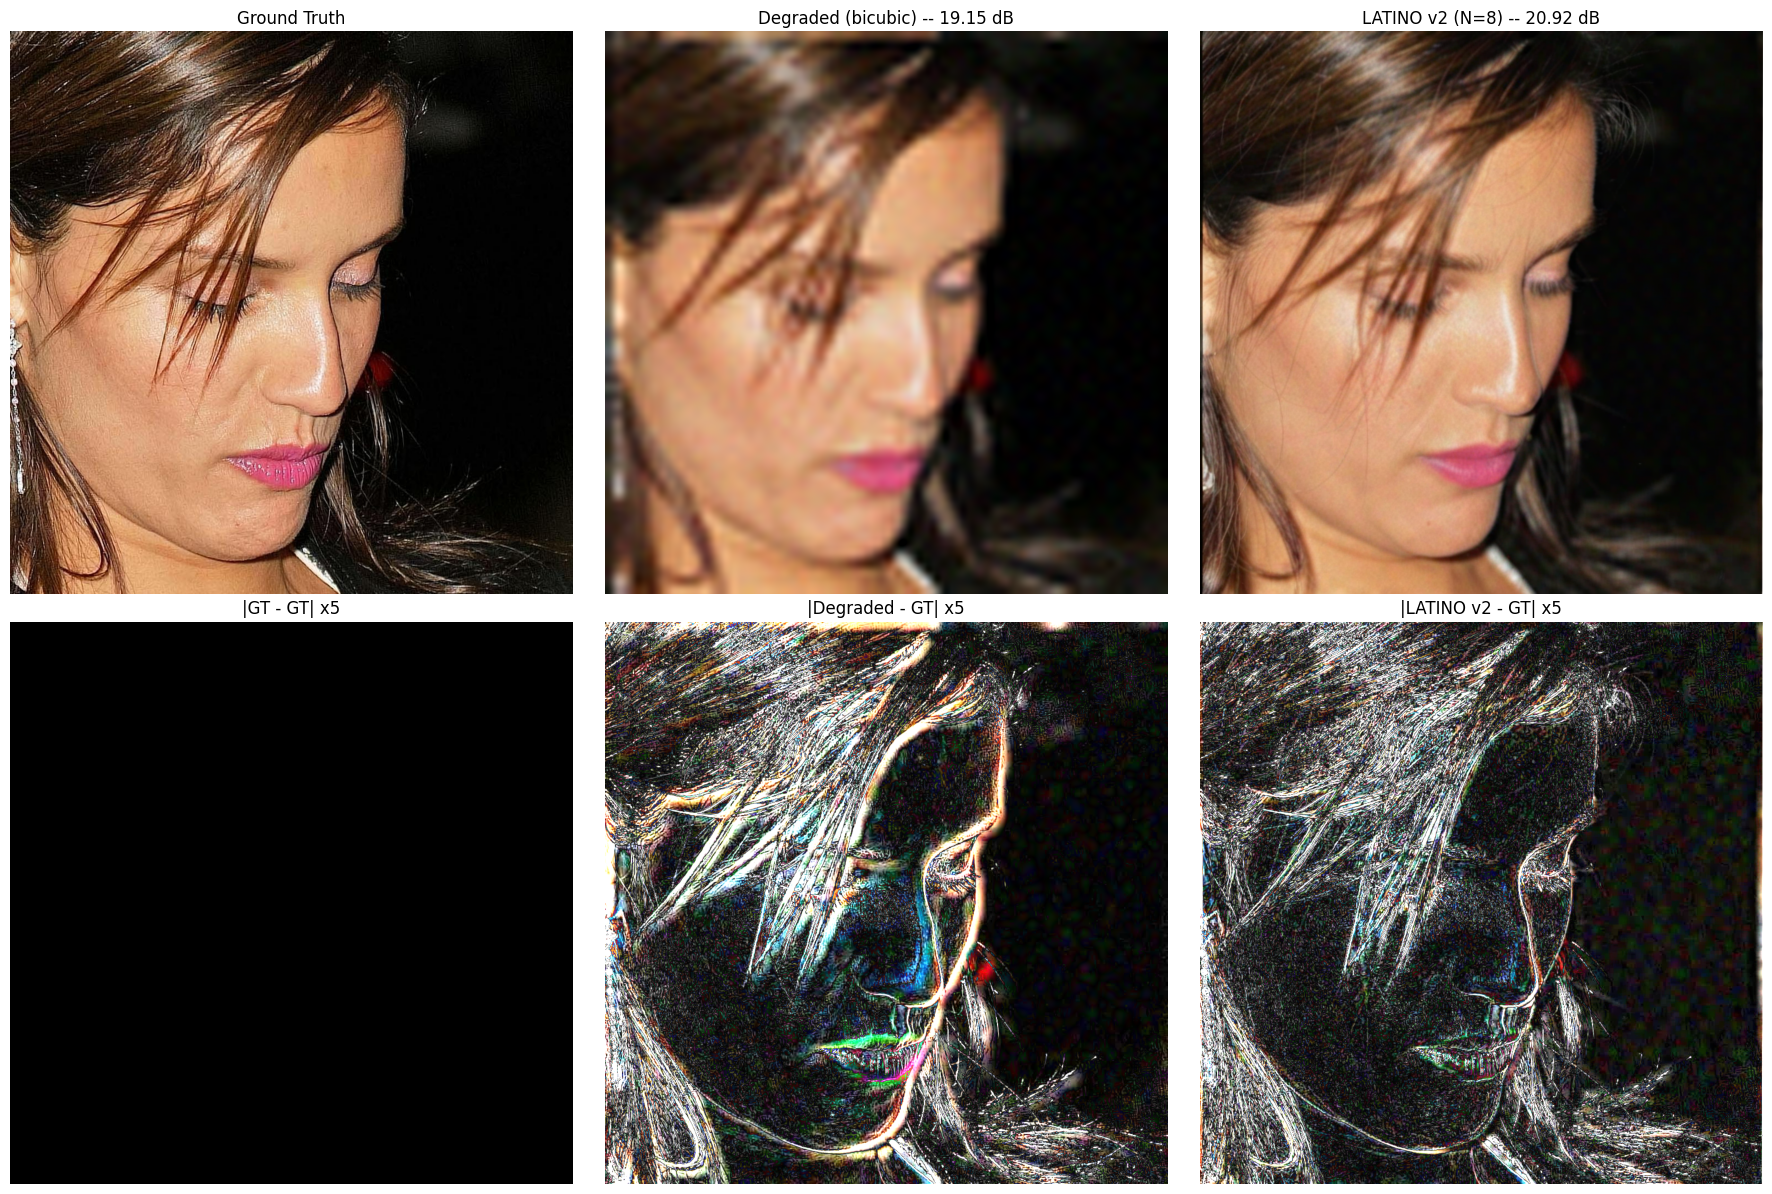

Saved comparison to output_v2/comparison_v2.png


In [9]:
gt_img = gt[0].cpu().permute(1, 2, 0)
yup_img = y_up[0].cpu().permute(1, 2, 0).clamp(0, 1)
res_img = result[0].cpu().permute(1, 2, 0).clamp(0, 1)

# Absolute error maps (amplified for visibility)
amp = 5
diff_gt = (gt_img - gt_img).abs() * amp
diff_yup = (yup_img - gt_img).abs() * amp
diff_res = (res_img - gt_img).abs() * amp

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: images
axes[0, 0].imshow(gt_img)
axes[0, 0].set_title("Ground Truth")
axes[0, 0].axis("off")

axes[0, 1].imshow(yup_img)
axes[0, 1].set_title(f"Degraded (bicubic) -- {baseline_psnr:.2f} dB")
axes[0, 1].axis("off")

axes[0, 2].imshow(res_img)
axes[0, 2].set_title(f"LATINO v2 (N={N}) -- {latino_psnr:.2f} dB")
axes[0, 2].axis("off")

# Row 2: |image - GT| x amp
axes[1, 0].imshow(diff_gt.clamp(0, 1))
axes[1, 0].set_title(f"|GT - GT| x{amp}")
axes[1, 0].axis("off")

axes[1, 1].imshow(diff_yup.clamp(0, 1))
axes[1, 1].set_title(f"|Degraded - GT| x{amp}")
axes[1, 1].axis("off")

axes[1, 2].imshow(diff_res.clamp(0, 1))
axes[1, 2].set_title(f"|LATINO v2 - GT| x{amp}")
axes[1, 2].axis("off")

plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "comparison_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved comparison to {OUTPUT_DIR}/comparison_v2.png")

## 10. Save Outputs

In [10]:
out = Path(OUTPUT_DIR)
save_image(gt, out / "ground_truth.png")
save_image(y_up.clamp(0, 1), out / "degraded_bicubic.png")
save_image(result.clamp(0, 1), out / "latino_v2_result.png")
print(f"Images saved to {out}/")

Images saved to output_v2/
